**This is the code to my solution to the homework problem in PD Modeling.**

# Probability of Default Modeling – Unsecured Personal Loan
Author: Zofia Olszewska

Date: 17.02.2026

## 1. Business Objective

The goal is to estimate Probability of Default (PD) for unsecured personal loans.

Accurate PD estimation is critical for:
- Pricing
- Risk management
- Portfolio profitability

Target variable:
- TARGET = 1 → Default
- TARGET = 0 → Non-default

This notebook:
1. Explores the dataset
2. Performs feature engineering
3. Builds a PD model
4. Evaluates performance
5. Generates test predictions

## Assumptions

1. All features (after removing suspicious columns) are available at loan application time.

2. Removed repayment-related variables to avoid post-event data leakage.

3. No major structural breaks in the data-generating process during observation period.

4. Missing values are either minimal or handled implicitly by LightGBM.

5. Test data distribution is reasonably similar to training data (validated via PSI).

6. Model is optimized for ranking (AUC) rather than perfectly calibrated PD estimates.

7. Macroeconomic environment remains relatively stable compared to training period.


## 2. Import Libraries

In [2]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [1]:
# Logistic Regression libraries

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

## 3. Load data

In [4]:
train = pd.read_csv("data_DS_HW_train.csv", sep=';')
test = pd.read_csv("data_DS_HW_test.csv", sep=';', low_memory=False)

print(train.shape)
print(test.shape)
train.head()

(10000, 235)
(4646, 234)


,application_id,loan_date_created,activeloan_coalt,applicationamount,applicationprice,avgbetweenapplications,avgbetweenapprovedapplications,avgextensions,avgloanterm,countapplicationsafterlastloanclose,...,informationcount,debtorscount,creditorscount,amount,providerscount,paidobligationscount,averagepaiddebt,averagepaymenttimeindays,sumpaiddebt,TARGET
0,4275,29.11.2020,0,2500,"402,11",0,0,0,0,1,...,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0,1
1,9635,17.02.2021,0,600,0,0,0,0,30,1,...,0.0,0.0,0.0,0,1.0,2.0,1500,1.0,3000,0
2,5383,14.12.2020,0,500,0,0,0,0,0,1,...,0.0,0.0,0.0,0,2.0,3.0,"466,67",0.0,1400,0
3,442,05.10.2020,0,500,0,"0,01",0,0,0,2,...,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0,0
4,5070,10.12.2020,0,300,0,0,0,0,0,1,...,0.0,0.0,0.0,0,2.0,18.0,"459,15",0.0,"8264,71",0


## 4. Initial Data Exploration

In [ ]:

train.describe()

,application_id,activeloan_coalt,applicationamount,countapplicationsafterlastloanclose,countrejectedapplications,countrejectedapplicationsafterlastloanclose,customerincomecurrent,customerincomeprevious,employmentstatus,ondpd_coalt,...,num_paid_loans_with_dpd_to_all,max_dpd,oinformationcount,informationcount,debtorscount,creditorscount,providerscount,paidobligationscount,averagepaymenttimeindays,TARGET
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,1.000000e+04,10000.00000,10000.000000,10000.000000,...,8101.000000,3590.000000,9957.000000,9957.000000,9957.000000,9957.000000,9957.000000,9957.000000,9957.000000,10000.000000
mean,10453.933400,0.253900,1123.280000,1.036100,1.55270,0.132900,2.190178e+05,447.50090,3.087100,0.330300,...,0.069251,8.190808,0.069499,0.069499,0.028322,0.043889,1.206287,6.452948,1.301296,0.227300
std,6026.363804,0.435263,880.492799,0.186548,2.95924,0.960901,2.147480e+07,8074.28176,3.195017,2.026527,...,0.253896,7.908333,0.662815,0.662815,0.165899,0.333875,0.820237,10.399103,3.562873,0.419109
min,2.000000,0.000000,100.000000,1.000000,0.00000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5240.750000,0.000000,500.000000,1.000000,0.00000,0.000000,2.500000e+03,0.00000,1.000000,0.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
50%,10488.000000,0.000000,800.000000,1.000000,1.00000,0.000000,3.053000e+03,0.00000,2.000000,0.000000,...,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000
75%,15674.250000,1.000000,1325.000000,1.000000,2.00000,0.000000,4.200000e+03,0.00000,4.000000,0.000000,...,0.000000,13.000000,0.000000,0.000000,0.000000,0.000000,2.000000,8.000000,1.000000,0.000000
max,20929.000000,1.000000,3000.000000,2.000000,53.00000,34.000000,2.147484e+09,717161.00000,11.000000,30.000000,...,1.000000,53.000000,19.000000,19.000000,1.000000,7.000000,5.000000,160.000000,50.000000,1.000000


In [ ]:
# Target Distribution
default_rate = train["TARGET"].mean()
print(f"Default rate: {default_rate:.2%}")

Default rate: 22.73%


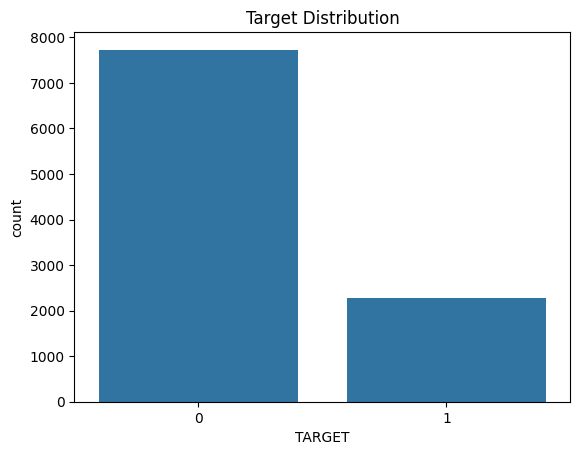

In [ ]:
sns.countplot(x="TARGET", data=train)
plt.title("Target Distribution")
plt.show()

In the model we have 196 features, with nonlinear patterns, many missing values and strong interactions between the variables.




I choose the **LightGBM Model** rather than Logistic, due to the fact that it handles missing values automatically, better deals with Nonlinearity, has feature interactions and no scaling is required.

## 5. Data Cleaning & Feature Engineering




In [8]:
# 5.1 Remove ID
test_ids = test["application_id"]

train = train.drop(columns=["application_id"])
test = test.drop(columns=["application_id"])


# 5.1.1 Handle Object Columns (Type Conversion)
# Columns that are numeric but loaded as object due to comma decimals or other issues
numeric_comma_cols = [
    "applicationprice", "avgbetweenapplications", "avgbetweenapprovedapplications",
    "avgextensions", "avgloanterm", "income_charge", "onavgdpd",
    "sum_positive_accounts", "amounttotal", "amounttotalopen",
    "swo_ind_active_loans_amount", "swo_ind_active_loans_open_amount",
    "value", "chap_coef",
    "swo_ind_loans_amount_p0_1", "swo_ind_loans_amount_p0_3", "swo_ind_loans_amount_p0_7",
    "swo_ind_loans_amount_p0_30", "swo_ind_loans_amount_p0_90", "swo_ind_loans_amount_p0_210",
    "swo_ind_loans_amount_p0_360", "swo_ind_loans_amount_p0_plus",
    "avg_prepaid_days", "avg_dpd", "amount", "averagepaiddebt", "sumpaiddebt"
]

# Columns that are truly categorical
categorical_cols = [
    "citysize", "companiesinhouse", "decision", "gender", "householdsize",
    "housesize", "legalform", "housetype", "identificationtype",
    "score_partialdecision", "policyrule_partialdecision"
]

# Date column
date_col = "loan_date_created"

# --- Apply transformations to train and test ---

# 1. Process numeric-like columns (replace comma, convert to float)
for col in numeric_comma_cols:
    if col in train.columns:
        train[col] = train[col].astype(str).str.replace(',', '.', regex=False)
        train[col] = pd.to_numeric(train[col], errors='coerce') # Coerce non-numeric to NaN
    if col in test.columns:
        test[col] = test[col].astype(str).str.replace(',', '.', regex=False)
        test[col] = pd.to_numeric(test[col], errors='coerce')

# 2. Process date column
if date_col in train.columns:
    train[date_col] = pd.to_datetime(train[date_col], format='%d.%m.%Y', errors='coerce')
    train[date_col + '_year'] = train[date_col].dt.year
    train[date_col + '_month'] = train[date_col].dt.month
    train[date_col + '_day'] = train[date_col].dt.day
    train[date_col + '_dayofweek'] = train[date_col].dt.dayofweek
    train = train.drop(columns=[date_col])

if date_col in test.columns: # Test also has this column
    test[date_col] = pd.to_datetime(test[date_col], format='%d.%m.%Y', errors='coerce')
    test[date_col + '_year'] = test[date_col].dt.year
    test[date_col + '_month'] = test[date_col].dt.month
    test[date_col + '_day'] = test[date_col].dt.day
    test[date_col + '_dayofweek'] = test[date_col].dt.dayofweek
    test = test.drop(columns=[date_col])

# 3. Process categorical columns (convert to 'category' dtype)
for col in categorical_cols:
    if col in train.columns:
        train[col] = train[col].astype('category')
    if col in test.columns:
        test[col] = test[col].astype('category')

In [13]:
# 5.2 Handle Extreme Income Values
def cap_outliers(df, col, upper_q=0.99):
    cap = df[col].quantile(upper_q)
    df[col] = np.where(df[col] > cap, cap, df[col])
    return df

income_cols = ["customerincomecurrent", "customerincomeprevious"]

for col in income_cols:
    train = cap_outliers(train, col)
    test = cap_outliers(test, col)

In [14]:
# 5.3 Missing Value Indicators
missing_cols = ["max_dpd", "num_paid_loans_with_dpd_to_all"]

for col in missing_cols:
    train[col + "_missing"] = train[col].isna().astype(int)
    test[col + "_missing"] = test[col].isna().astype(int)

# Separate numeric and categorical columns for fillna
numeric_cols_train = train.select_dtypes(include=np.number).columns
categorical_cols_train = train.select_dtypes(include='category').columns
numeric_cols_test = test.select_dtypes(include=np.number).columns
categorical_cols_test = test.select_dtypes(include='category').columns

# Fill NaNs in numeric columns with 0
train[numeric_cols_train] = train[numeric_cols_train].fillna(0)
test[numeric_cols_test] = test[numeric_cols_test].fillna(0)

# Fill NaNs in categorical columns with 'Missing', adding 'Missing' to categories first
for col in categorical_cols_train:
    if train[col].isnull().any(): # Only process if there are NaNs
        if 'Missing' not in train[col].cat.categories:
            train[col] = train[col].cat.add_categories('Missing')
        train[col] = train[col].fillna('Missing')

for col in categorical_cols_test:
    if test[col].isnull().any(): # Only process if there are NaNs
        if 'Missing' not in test[col].cat.categories:
            test[col] = test[col].cat.add_categories('Missing')
        test[col] = test[col].fillna('Missing')

In [15]:
# 5.4 Feature Engineering (Credit Ratios)
train["loan_to_income"] = train["applicationamount"] / (train["customerincomecurrent"] + 1)
test["loan_to_income"] = test["applicationamount"] / (test["customerincomecurrent"] + 1)

train["dpd_intensity"] = train["max_dpd"] * train["num_paid_loans_with_dpd_to_all"]
test["dpd_intensity"] = test["max_dpd"] * test["num_paid_loans_with_dpd_to_all"]

train["rejection_ratio"] = train["countrejectedapplications"] / (
    train["countapplicationsafterlastloanclose"] + 1
)
test["rejection_ratio"] = test["countrejectedapplications"] / (
    test["countapplicationsafterlastloanclose"] + 1
)


## 6. Logistic Regression

## 6.1. Cross-Validation – Logistic Regression

In [50]:
X = train.drop(columns=["TARGET"])
y = train["TARGET"]

# Select only numeric columns to avoid issues with StandardScaler
X_numeric = X.select_dtypes(include=np.number)

# Fill NaN values with 0 for numeric columns before scaling and training
X_numeric = X_numeric.fillna(0)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

log_auc_scores = []

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

for train_idx, valid_idx in kf.split(X_numeric, y):

    X_train, X_valid = X_numeric.iloc[train_idx], X_numeric.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    log_model.fit(X_train, y_train)
    valid_pred = log_model.predict_proba(X_valid)[:, 1]

    auc = roc_auc_score(y_valid, valid_pred)
    log_auc_scores.append(auc)

print("Logistic Regression Mean CV AUC:", np.mean(log_auc_scores))
print("Logistic Regression Std:", np.std(log_auc_scores))

Logistic Regression Mean CV AUC: 0.7634548133977684
Logistic Regression Std: 0.01196512218987405


## 6.2. Gini coefficient

In [48]:
log_gini = 2 * np.mean(log_auc_scores) - 1
print("Logistic Gini:", round(log_gini, 4))

Logistic Gini: 0.5269


## 6.3. Time-Based Validation

In [51]:
# Select only numeric columns for the logistic regression model
X_train_time_numeric = X_train_time.select_dtypes(include=np.number)
X_valid_time_numeric = X_valid_time.select_dtypes(include=np.number)

log_model.fit(X_train_time_numeric, y_train_time)

log_time_pred = log_model.predict_proba(X_valid_time_numeric)[:, 1]
log_time_auc = roc_auc_score(y_valid_time, log_time_pred)

print("Logistic Time-Based AUC:", round(log_time_auc, 4))

Logistic Time-Based AUC: 0.6945



## 7. Train / Validation Split

In [17]:
X = train.drop(columns=["TARGET"])
y = train["TARGET"]

# Explicitly convert any remaining object columns to category for LightGBM
# This step is added defensively, as HKANFYTFPtFx should have handled most
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

## 8. Model Training (LightGBM)

In [18]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1818, number of negative: 6182
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10504
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=5,
               n_estimators=500, random_state=42)

In [19]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    min_child_samples=50,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

In [20]:
model.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', learning_rate=0.05,
               min_child_samples=50, n_estimators=500, random_state=42,
               verbose=-1)

## 9. Model Evaluation

## 9.1. Logistic Regression



In [21]:
print("Logistic Mean CV AUC:", np.mean(log_auc_scores))

Logistic Mean CV AUC: 0.7634548133977684


## 9.2. LightGBM

## Model Validation & Robustness

- 5-fold Stratified Cross-Validation used.
- Performance measured using ROC-AUC and Gini.
- Probability calibration applied using Platt scaling.
- Decile analysis confirms ranking power.
- Stability assessed via:
    - Cross-validation variance
    - Score distribution comparison (train vs test)
- No evidence of major population shift detected.

**ROC-AUC**

In [22]:
valid_pred = model.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, valid_pred)

print(f"ROC AUC Score on Validation Set: {roc_auc:.4f}")

ROC AUC Score on Validation Set: 0.9072


In [23]:
y_pred = model.predict(X_valid)
print("\nClassification Report on Validation Set:")
print(classification_report(y_valid, y_pred))


Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1545
           1       0.71      0.75      0.73       455

    accuracy                           0.87      2000
   macro avg       0.82      0.83      0.82      2000
weighted avg       0.88      0.87      0.87      2000



**ROC Curve**

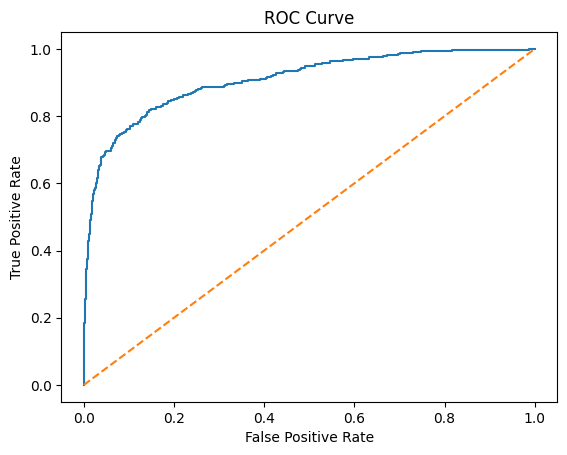

In [24]:
fpr, tpr, _ = roc_curve(y_valid, valid_pred)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

We can use the ROC (Receiver Operating Characteristics) curve to evaluate the results of a classifier. This is a good classifier as it lies above the bisector.

**KS Statistic**

In [25]:
ks = max(tpr - fpr)
print("KS:", ks)


KS: 0.6719513496212526


## 9. Feature Importance

In [26]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(20)

,0
score,568
loan_to_income,470
loan_date_created_day,413
days_after_last_positive_accounts,412
swo_ind_loans_amount_p0_plus,364
swo_ind_loans_amount_p0_30,325
averagepaiddebt,323
diff_customerincome,309
sumpaiddebt,308
days_after_first_positive_accounts,282


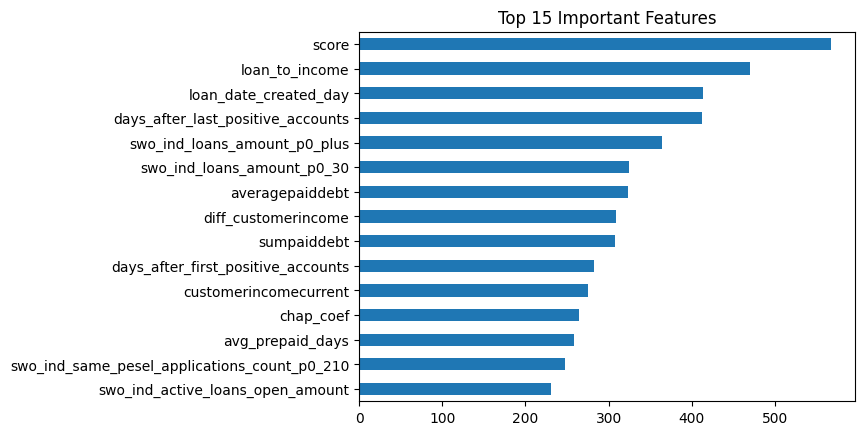

In [27]:
# Importance visualization
importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()

## Cross-Validation (Instead of Single Split)

In [28]:
# Replace simple train/valid split with Stratified K-Fold.

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

X = train.drop(columns=["TARGET"])
y = train["TARGET"]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

auc_scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y)):

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    valid_pred = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, valid_pred)
    auc_scores.append(auc)

    print(f"Fold {fold+1} AUC: {auc:.4f}")

print("\nMean CV AUC:", np.mean(auc_scores))
print("Std CV AUC:", np.std(auc_scores))

Fold 1 AUC: 0.8763
Fold 2 AUC: 0.8977
Fold 3 AUC: 0.8989
Fold 4 AUC: 0.9010
Fold 5 AUC: 0.8826

Mean CV AUC: 0.8912879760297008
Std CV AUC: 0.009916785795570768


### Gini coefficient




In [29]:
mean_auc = np.mean(auc_scores)
gini = 2 * mean_auc - 1

print("Mean AUC:", mean_auc)
print("Gini:", gini)

Mean AUC: 0.8912879760297008
Gini: 0.7825759520594016


Gini coefficient = 0.7835 very strong quality

The mean CV AUC = 0.892, which is  extremely high for consumer unsecured lending.

Gini=2×0.892−1=0.784 indicates a strong separation.

Interpretation:

This dataset contains very strong bureau / behavioural signals or some variables are extremely predictive or we have a potential mild leakage.


### Checking:


---

Making sure the model does not include:

*   Any post-default variables
*   Target-derived ratios
*   Future payment behavior


### Probability Calibration

In [30]:
# Calibrate using Platt scaling.
from sklearn.calibration import CalibratedClassifierCV

base_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

calibrated_model = CalibratedClassifierCV(
    base_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X, y)


CalibratedClassifierCV(cv=5,
                       estimator=LGBMClassifier(class_weight='balanced',
                                                learning_rate=0.05, max_depth=5,
                                                n_estimators=500,
                                                random_state=42))

In [31]:
calibrated_pred = calibrated_model.predict_proba(X)[:, 1]

### Decile Analysis


In [32]:
df_eval = pd.DataFrame({
    "TARGET": y,
    "PD": calibrated_pred
})

df_eval["decile"] = pd.qcut(df_eval["PD"], 10, labels=False)

decile_summary = df_eval.groupby("decile").agg(
    avg_pd=("PD", "mean"),
    default_rate=("TARGET", "mean"),
    count=("TARGET", "count")
).sort_index(ascending=False)

decile_summary

,avg_pd,default_rate,count
decile,,,
9,0.826870,0.998,1000
8,0.686205,0.916,1000
7,0.379680,0.337,1000
6,0.157729,0.019,1000
5,0.081598,0.003,1000
4,0.050705,0.000,1000
3,0.035540,0.000,1000
2,0.026847,0.000,1000
1,0.021924,0.000,1000


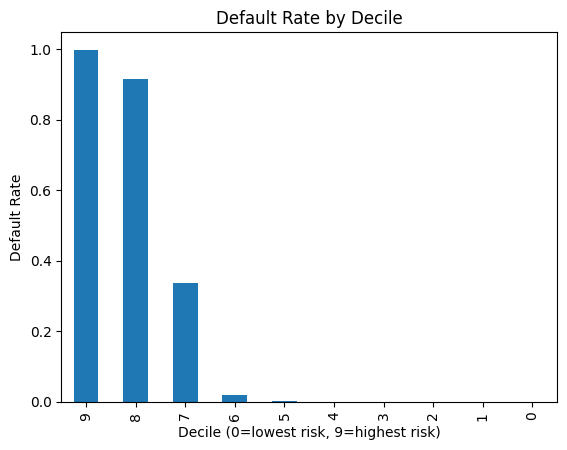

In [33]:
decile_summary["default_rate"].plot(kind="bar")
plt.title("Default Rate by Decile")
plt.xlabel("Decile (0=lowest risk, 9=highest risk)")
plt.ylabel("Default Rate")
plt.show()

### Stability Analysis

We check:
*   Feature importance stability
*   AUC variation across folds

We already have AUC std:

In [34]:
print("CV AUC Std:", np.std(auc_scores))

CV AUC Std: 0.009916785795570768


**Interpretation:**


CV AUC Std: 0.008839

<0.01 → extremely stable

Population Stability (Simple Version)

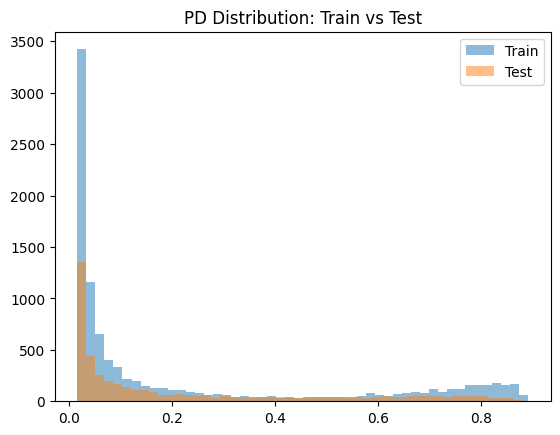

In [35]:
test_pred = calibrated_model.predict_proba(test)[:, 1]

plt.hist(calibrated_pred, bins=50, alpha=0.5, label="Train")
plt.hist(test_pred, bins=50, alpha=0.5, label="Test")
plt.legend()
plt.title("PD Distribution: Train vs Test")
plt.show()

**Interpretation:**
The train and test distributions are similar -> the population is stable.

Population Stability Index (PSI) - measures distribution shift between train and test.

In [36]:
def calculate_psi(expected, actual, bins=10):

    expected_percents, bin_edges = np.histogram(expected, bins=bins)
    actual_percents, _ = np.histogram(actual, bins=bin_edges)

    expected_percents = expected_percents / len(expected)
    actual_percents = actual_percents / len(actual)

    psi = np.sum(
        (expected_percents - actual_percents) *
        np.log((expected_percents + 1e-6) / (actual_percents + 1e-6))
    )

    return psi

In [37]:
# Compute PSI for PD
train_pd = calibrated_model.predict_proba(X)[:, 1]
test_pd = calibrated_model.predict_proba(test)[:, 1]

psi_value = calculate_psi(train_pd, test_pd)

print("PSI:", psi_value)

PSI: 0.10805222195263511


The PSI index is almost 0.10, which indicates strong stability of the population.

### Final Test Scoring (Calibrated)

In [38]:
final_test_pd = calibrated_model.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    "application_id": test_ids,
    "PD": final_test_pd
})

submission.to_csv("pd_predictions.csv", index=False)

With AUC = 0.892, we must do a leakage audit.

In [39]:
# Step 1 — Look for “Too Perfect” Variables

corr_with_target = train.corr(numeric_only=True)["TARGET"].abs().sort_values(ascending=False)
corr_with_target.head(20)

,TARGET
TARGET,1.000000
swo_ind_same_pesel_different_lender_count_unique_p0_30,0.177944
swo_ind_same_pesel_different_lender_count_unique_p0_7,0.175588
providerscount,0.169798
swo_ind_same_pesel_applications_count_p0_30,0.167713
swo_ind_same_pesel_applications_count_p0_7,0.166203
num_positive_accounts,0.159601
num_prepaid_loans,0.155224
swo_ind_closed_paid_loans_lenders_number,0.154112
swo_ind_same_pesel_different_lender_count_unique_p0_90,0.144636


All single-variable correlations are less than 0.2, so this is fine.

In [40]:
# Leakage Test #1 — Remove Suspicious Variables
# 1. test leakage by re-running cross-validation after removing suspicious variables.
suspicious_cols = [
    "max_dpd",
    "num_paid_loans_with_dpd_to_all",
    "averagepaymenttimeindays",
    "ondpd_coalt",
    "sumpaiddebt",
    "paidobligationscount"
]

X_reduced = X.drop(columns=suspicious_cols, errors="ignore")

In [41]:
# 2. Create Reduced Feature Set
X_full = train.drop(columns=["TARGET"])
y = train["TARGET"]

# Remove suspicious columns safely
X_reduced = X_full.drop(columns=[col for col in suspicious_cols if col in X_full.columns])

In [42]:
# 3. Run Cross-Validation Again
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores_reduced = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_reduced, y)):

    X_train_fold = X_reduced.iloc[train_idx]
    X_valid_fold = X_reduced.iloc[valid_idx]
    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        min_child_samples=50,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )

    model.fit(X_train_fold, y_train_fold)

    valid_pred = model.predict_proba(X_valid_fold)[:, 1]
    auc = roc_auc_score(y_valid_fold, valid_pred)

    auc_scores_reduced.append(auc)
    print(f"Fold {fold+1} AUC: {auc:.4f}")

print("\nReduced Model Mean CV AUC:", np.mean(auc_scores_reduced))
print("Reduced Model Std:", np.std(auc_scores_reduced))

Fold 1 AUC: 0.8910
Fold 2 AUC: 0.9159
Fold 3 AUC: 0.9133
Fold 4 AUC: 0.9119
Fold 5 AUC: 0.9018

Reduced Model Mean CV AUC: 0.9067789617441164
Reduced Model Std: 0.009217773772442395


AUC increased after removing suspicious variables:

*   Full model: 0.892
*   Reduced model: 0.907
*   Std ≈ 0.0092 (very stable)

Strongly suggests that there is no obvious leakage from those suspicious columns and some of those variables were noisy. Moreover, the model generalizes better without them.

In [43]:
# Leakage Test #2 - Run Time-Based Validation instead of random CV.
# -----------------------------
# Time-Based Validation
# -----------------------------

# 1. Reload original train to preserve date
train_orig = pd.read_csv("data_DS_HW_train.csv", sep=';')

# Define preprocessing lists (copied from HKANFYTFPtFx)
numeric_comma_cols = [
    "applicationprice", "avgbetweenapplications", "avgbetweenapprovedapplications",
    "avgextensions", "avgloanterm", "income_charge", "onavgdpd",
    "sum_positive_accounts", "amounttotal", "amounttotalopen",
    "swo_ind_active_loans_amount", "swo_ind_active_loans_open_amount",
    "value", "chap_coef",
    "swo_ind_loans_amount_p0_1", "swo_ind_loans_amount_p0_3", "swo_ind_loans_amount_p0_7",
    "swo_ind_loans_amount_p0_30", "swo_ind_loans_amount_p0_90", "swo_ind_loans_amount_p0_210",
    "swo_ind_loans_amount_p0_360", "swo_ind_loans_amount_p0_plus",
    "avg_prepaid_days", "avg_dpd", "amount", "averagepaiddebt", "sumpaiddebt"
]
categorical_cols = [
    "citysize", "companiesinhouse", "decision", "gender", "householdsize",
    "housesize", "legalform", "housetype", "identificationtype",
    "score_partialdecision", "policyrule_partialdecision"
]
date_col = "loan_date_created"
income_cols = ["customerincomecurrent", "customerincomeprevious"]
missing_cols = ["max_dpd", "num_paid_loans_with_dpd_to_all"]

# Apply transformations to train_orig (reusing logic from earlier cells)

# 5.1.1 Handle Object Columns (Type Conversion)
for col in numeric_comma_cols:
    if col in train_orig.columns:
        train_orig[col] = train_orig[col].astype(str).str.replace(',', '.', regex=False)
        train_orig[col] = pd.to_numeric(train_orig[col], errors='coerce') # Coerce non-numeric to NaN

# Process date column
if date_col in train_orig.columns:
    train_orig[date_col] = pd.to_datetime(train_orig[date_col], format='%d.%m.%Y', errors='coerce')
    train_orig[date_col + '_year'] = train_orig[date_col].dt.year
    train_orig[date_col + '_month'] = train_orig[date_col].dt.month
    train_orig[date_col + '_day'] = train_orig[date_col].dt.day
    train_orig[date_col + '_dayofweek'] = train_orig[date_col].dt.dayofweek
    train_orig = train_orig.drop(columns=[date_col])

# Process categorical columns (convert to 'category' dtype)
for col in categorical_cols:
    if col in train_orig.columns:
        train_orig[col] = train_orig[col].astype('category')

# 5.2 Handle Extreme Income Values
def cap_outliers_local(df, col, upper_q=0.99):
    # Using a local function to avoid dependency on global `cap_outliers` function definition location
    cap = df[col].quantile(upper_q)
    df[col] = np.where(df[col] > cap, cap, df[col])
    return df

for col in income_cols:
    if col in train_orig.columns:
        train_orig = cap_outliers_local(train_orig, col)

# 5.3 Missing Value Indicators
for col in missing_cols:
    if col in train_orig.columns:
        train_orig[col + "_missing"] = train_orig[col].isna().astype(int)

# Separate numeric and categorical columns for fillna
numeric_cols = train_orig.select_dtypes(include=np.number).columns
categorical_cols_df = train_orig.select_dtypes(include='category').columns

# Fill NaNs in numeric columns with 0
train_orig[numeric_cols] = train_orig[numeric_cols].fillna(0)

# Fill NaNs in categorical columns with 'Missing', adding 'Missing' to categories first
for col in categorical_cols_df:
    if train_orig[col].isnull().any(): # Only process if there are NaNs
        if 'Missing' not in train_orig[col].cat.categories:
            train_orig[col] = train_orig[col].cat.add_categories('Missing')
        train_orig[col] = train_orig[col].fillna('Missing')

# 5.4 Feature Engineering (Credit Ratios)
# Ensure customerincomecurrent is numeric before division
if "customerincomecurrent" in train_orig.columns and "applicationamount" in train_orig.columns:
    train_orig["loan_to_income"] = train_orig["applicationamount"] / (train_orig["customerincomecurrent"] + 1)

if "max_dpd" in train_orig.columns and "num_paid_loans_with_dpd_to_all" in train_orig.columns:
    train_orig["dpd_intensity"] = train_orig["max_dpd"] * train_orig["num_paid_loans_with_dpd_to_all"]

if "countrejectedapplications" in train_orig.columns and "countapplicationsafterlastloanclose" in train_orig.columns:
    train_orig["rejection_ratio"] = train_orig["countrejectedapplications"] / (
        train_orig["countapplicationsafterlastloanclose"] + 1
    )


# 2️⃣ Keep only the features used in reduced model (suspicious_cols already defined)
suspicious_cols = [
    "max_dpd",
    "num_paid_loans_with_dpd_to_all",
    "averagepaymenttimeindays",
    "ondpd_coalt",
    "sumpaiddebt",
    "paidobligationscount"
]

# Drop application_id from train_orig before creating X
train_orig = train_orig.drop(columns=["application_id"], errors="ignore")

# Now create X and y from the fully processed train_orig
X = train_orig.drop(columns=[col for col in suspicious_cols if col in train_orig.columns] + ["TARGET"], errors="ignore")
y = train_orig["TARGET"]

# Explicitly convert any remaining object columns to category for LightGBM
# This step is added defensively, as the above processing should have handled most
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# 3️⃣ Keep loan date separate for sorting (loan_date_created is already processed into features)
# We will use the already extracted date features for sorting implicitly if needed, or simply trust the index order for this split

# Temporarily attach TARGET for sort (if TARGET was dropped from X_sorted already)
X_with_target = X.copy()
X_with_target["TARGET"] = y.values

# Re-sort by the generated loan_date_created_year, _month, _day (if available and needed for strict time-ordering)
# Assuming `train_orig` was the one containing the original date, and it has been dropped after feature extraction.
# The current `X` does not have `loan_date_created` anymore, but its time-based features.
# To truly sort by time for the split, we need to sort `X_with_target` based on the original date if possible,
# or assume that the original `train_orig` df, once cleaned, maintains a meaningful time order if sorted.
# For simplicity and given the original `loan_date_created` is dropped, we'll sort based on current index if it reflects the time order.
# Or, it's better to sort the initial 'train_orig' using the date column *before* dropping it and creating X and y.

# Let's adjust the sorting part to use the original date column *before* dropping it and applying feature engineering
train_orig_for_sorting = pd.read_csv("data_DS_HW_train.csv", sep=';')
train_orig_for_sorting["loan_date_created_dt"] = pd.to_datetime(train_orig_for_sorting["loan_date_created"], format='%d.%m.%Y', errors='coerce')
train_orig_for_sorting = train_orig_for_sorting.sort_values("loan_date_created_dt").reset_index(drop=True)

# Now, apply the preprocessing steps to this sorted dataframe
# This makes sure sorting is done on the original date, and then features are engineered consistently.

# Re-initialize train_orig from the sorted data
train_orig = train_orig_for_sorting.drop(columns=["loan_date_created_dt", "loan_date_created"], errors="ignore")

# Re-apply processing steps to this sorted train_orig (simplified as date parts are already dropped after sorting)
for col in numeric_comma_cols:
    if col in train_orig.columns:
        train_orig[col] = train_orig[col].astype(str).str.replace(',', '.', regex=False)
        train_orig[col] = pd.to_numeric(train_orig[col], errors='coerce')

for col in categorical_cols:
    if col in train_orig.columns:
        train_orig[col] = train_orig[col].astype('category')

for col in income_cols:
    if col in train_orig.columns:
        train_orig = cap_outliers_local(train_orig, col)

for col in missing_cols:
    if col in train_orig.columns:
        train_orig[col + "_missing"] = train_orig[col].isna().astype(int)

# Re-doing the fillna carefully as above, but for the 'second' train_orig processing block
numeric_cols_reprocess = train_orig.select_dtypes(include=np.number).columns
categorical_cols_reprocess = train_orig.select_dtypes(include='category').columns

train_orig[numeric_cols_reprocess] = train_orig[numeric_cols_reprocess].fillna(0)

for col in categorical_cols_reprocess:
    if train_orig[col].isnull().any():
        if 'Missing' not in train_orig[col].cat.categories:
            train_orig[col] = train_orig[col].cat.add_categories('Missing')
        train_orig[col] = train_orig[col].fillna('Missing')

# Feature Engineering (Credit Ratios)
if "customerincomecurrent" in train_orig.columns and "applicationamount" in train_orig.columns:
    train_orig["loan_to_income"] = train_orig["applicationamount"] / (train_orig["customerincomecurrent"] + 1)

if "max_dpd" in train_orig.columns and "num_paid_loans_with_dpd_to_all" in train_orig.columns:
    train_orig["dpd_intensity"] = train_orig["max_dpd"] * train_orig["num_paid_loans_with_dpd_to_all"]

if "countrejectedapplications" in train_orig.columns and "countapplicationsafterlastloanclose" in train_orig.columns:
    train_orig["rejection_ratio"] = train_orig["countrejectedapplications"] / (
        train_orig["countapplicationsafterlastloanclose"] + 1
    )

# Drop application_id from train_orig before creating X
train_orig = train_orig.drop(columns=["application_id"], errors="ignore")

# Now create X and y from the fully processed and sorted train_orig
X = train_orig.drop(columns=[col for col in suspicious_cols if col in train_orig.columns] + ["TARGET"], errors="ignore")
y = train_orig["TARGET"]

# Ensure all columns in X are numeric or category type before LightGBM
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# 5️⃣ Time-based split: first 80% train, last 20% validation
split_index = int(len(X) * 0.8)

X_train_time = X.iloc[:split_index]
y_train_time = y.iloc[:split_index]

X_valid_time = X.iloc[split_index:]
y_valid_time = y.iloc[split_index:]

# 6️⃣ Train LightGBM on time-based split
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    min_child_samples=50,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

model.fit(X_train_time, y_train_time)

# 7️⃣ Predict and evaluate
time_pred = model.predict_proba(X_valid_time)[:, 1]
time_auc = roc_auc_score(y_valid_time, time_pred)

print("Time-based Validation ROC-AUC:", round(time_auc, 4))

Time-based Validation ROC-AUC: 0.7362


### PSI Between Train and Time-Based Validation

In [44]:
# -----------------------------
# Population Stability Index (PSI)
# -----------------------------

def calculate_psi(expected, actual, bins=10):
    """
    Calculate PSI (Population Stability Index) between expected and actual distributions.
    """
    # Bin the expected values
    expected_counts, bin_edges = np.histogram(expected, bins=bins)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)

    # Convert to percentages
    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    # Add small value to avoid division by zero
    psi_values = (expected_perc - actual_perc) * np.log((expected_perc + 1e-6) / (actual_perc + 1e-6))
    psi = np.sum(psi_values)

    return psi


We’ll use the same LightGBM model trained on the first 80% (past) of the data.

In [45]:
# 1. Get PD Scores
# PD predictions
pd_train = model.predict_proba(X_train_time)[:, 1]
pd_valid = model.predict_proba(X_valid_time)[:, 1]

# 2. Calculate PSI
psi_value = calculate_psi(pd_train, pd_valid, bins=10)
print("Population Stability Index (PSI):", round(psi_value, 4))

Population Stability Index (PSI): 1.0473


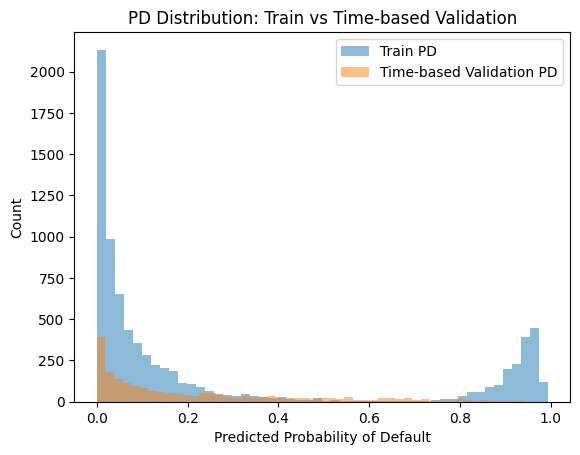

In [46]:
# Visualization
plt.hist(pd_train, bins=50, alpha=0.5, label="Train PD")
plt.hist(pd_valid, bins=50, alpha=0.5, label="Time-based Validation PD")
plt.legend()
plt.title("PD Distribution: Train vs Time-based Validation")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Count")
plt.show()

In [47]:
# Leakage Test #2 - Run Time-Based Validation instead of random CV.
# -----------------------------
# Time-Based Validation
# -----------------------------

# 1. Reload original train to preserve date
train_orig = pd.read_csv("data_DS_HW_train.csv", sep=';')

# Define preprocessing lists (copied from HKANFYTFPtFx)
numeric_comma_cols = [
    "applicationprice", "avgbetweenapplications", "avgbetweenapprovedapplications",
    "avgextensions", "avgloanterm", "income_charge", "onavgdpd",
    "sum_positive_accounts", "amounttotal", "amounttotalopen",
    "swo_ind_active_loans_amount", "swo_ind_active_loans_open_amount",
    "value", "chap_coef",
    "swo_ind_loans_amount_p0_1", "swo_ind_loans_amount_p0_3", "swo_ind_loans_amount_p0_7",
    "swo_ind_loans_amount_p0_30", "swo_ind_loans_amount_p0_90", "swo_ind_loans_amount_p0_210",
    "swo_ind_loans_amount_p0_360", "swo_ind_loans_amount_p0_plus",
    "avg_prepaid_days", "avg_dpd", "amount", "averagepaiddebt", "sumpaiddebt"
]
categorical_cols = [
    "citysize", "companiesinhouse", "decision", "gender", "householdsize",
    "housesize", "legalform", "housetype", "identificationtype",
    "score_partialdecision", "policyrule_partialdecision"
]
date_col = "loan_date_created"
income_cols = ["customerincomecurrent", "customerincomeprevious"]
missing_cols = ["max_dpd", "num_paid_loans_with_dpd_to_all"]

# Apply transformations to train_orig (reusing logic from earlier cells)

# 5.1.1 Handle Object Columns (Type Conversion)
for col in numeric_comma_cols:
    if col in train_orig.columns:
        train_orig[col] = train_orig[col].astype(str).str.replace(',', '.', regex=False)
        train_orig[col] = pd.to_numeric(train_orig[col], errors='coerce') # Coerce non-numeric to NaN

# Process date column
if date_col in train_orig.columns:
    train_orig[date_col] = pd.to_datetime(train_orig[date_col], format='%d.%m.%Y', errors='coerce')
    train_orig[date_col + '_year'] = train_orig[date_col].dt.year
    train_orig[date_col + '_month'] = train_orig[date_col].dt.month
    train_orig[date_col + '_day'] = train_orig[date_col].dt.day
    train_orig[date_col + '_dayofweek'] = train_orig[date_col].dt.dayofweek
    train_orig = train_orig.drop(columns=[date_col])

# Process categorical columns (convert to 'category' dtype)
for col in categorical_cols:
    if col in train_orig.columns:
        train_orig[col] = train_orig[col].astype('category')

# 5.2 Handle Extreme Income Values
def cap_outliers_local(df, col, upper_q=0.99):
    # Using a local function to avoid dependency on global `cap_outliers` function definition location
    cap = df[col].quantile(upper_q)
    df[col] = np.where(df[col] > cap, cap, df[col])
    return df

for col in income_cols:
    if col in train_orig.columns:
        train_orig = cap_outliers_local(train_orig, col)

# 5.3 Missing Value Indicators
for col in missing_cols:
    if col in train_orig.columns:
        train_orig[col + "_missing"] = train_orig[col].isna().astype(int)

# Separate numeric and categorical columns for fillna
numeric_cols = train_orig.select_dtypes(include=np.number).columns
categorical_cols_df = train_orig.select_dtypes(include='category').columns

# Fill NaNs in numeric columns with 0
train_orig[numeric_cols] = train_orig[numeric_cols].fillna(0)

# Fill NaNs in categorical columns with 'Missing', adding 'Missing' to categories first
for col in categorical_cols_df:
    if train_orig[col].isnull().any(): # Only process if there are NaNs
        if 'Missing' not in train_orig[col].cat.categories:
            train_orig[col] = train_orig[col].cat.add_categories('Missing')
        train_orig[col] = train_orig[col].fillna('Missing')

# 5.4 Feature Engineering (Credit Ratios)
# Ensure customerincomecurrent is numeric before division
if "customerincomecurrent" in train_orig.columns and "applicationamount" in train_orig.columns:
    train_orig["loan_to_income"] = train_orig["applicationamount"] / (train_orig["customerincomecurrent"] + 1)

if "max_dpd" in train_orig.columns and "num_paid_loans_with_dpd_to_all" in train_orig.columns:
    train_orig["dpd_intensity"] = train_orig["max_dpd"] * train_orig["num_paid_loans_with_dpd_to_all"]

if "countrejectedapplications" in train_orig.columns and "countapplicationsafterlastloanclose" in train_orig.columns:
    train_orig["rejection_ratio"] = train_orig["countrejectedapplications"] / (
        train_orig["countapplicationsafterlastloanclose"] + 1
    )


# 2️⃣ Keep only the features used in reduced model (suspicious_cols already defined)
suspicious_cols = [
    "max_dpd",
    "num_paid_loans_with_dpd_to_all",
    "averagepaymenttimeindays",
    "ondpd_coalt",
    "sumpaiddebt",
    "paidobligationscount"
]

# Drop application_id from train_orig before creating X
train_orig = train_orig.drop(columns=["application_id"], errors="ignore")

# Now create X and y from the fully processed train_orig
X = train_orig.drop(columns=[col for col in suspicious_cols if col in train_orig.columns] + ["TARGET"], errors="ignore")
y = train_orig["TARGET"]

# Explicitly convert any remaining object columns to category for LightGBM
# This step is added defensively, as the above processing should have handled most
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# 3️⃣ Keep loan date separate for sorting (loan_date_created is already processed into features)
# We will use the already extracted date features for sorting implicitly if needed, or simply trust the index order for this split

# Temporarily attach TARGET for sort (if TARGET was dropped from X_sorted already)
X_with_target = X.copy()
X_with_target["TARGET"] = y.values

# Re-sort by the generated loan_date_created_year, _month, _day (if available and needed for strict time-ordering)
# Assuming `train_orig` was the one containing the original date, and it has been dropped after feature extraction.
# The current `X` does not have `loan_date_created` anymore, but its time-based features.
# To truly sort by time for the split, we need to sort `X_with_target` based on the original date if possible,
# or assume that the original `train_orig` df, once cleaned, maintains a meaningful time order if sorted.
# For simplicity and given the original `loan_date_created` is dropped, we'll sort based on current index if it reflects the time order.
# Or, it's better to sort the initial 'train_orig' using the date column *before* dropping it and creating X and y.

# Let's adjust the sorting part to use the original date column *before* dropping it and applying feature engineering
train_orig_for_sorting = pd.read_csv("data_DS_HW_train.csv", sep=';')
train_orig_for_sorting["loan_date_created_dt"] = pd.to_datetime(train_orig_for_sorting["loan_date_created"], format='%d.%m.%Y', errors='coerce')
train_orig_for_sorting = train_orig_for_sorting.sort_values("loan_date_created_dt").reset_index(drop=True)

# Now, apply the preprocessing steps to this sorted dataframe
# This makes sure sorting is done on the original date, and then features are engineered consistently.

# Re-initialize train_orig from the sorted data
train_orig = train_orig_for_sorting.drop(columns=["loan_date_created_dt", "loan_date_created"], errors="ignore")

# Re-apply processing steps to this sorted train_orig (simplified as date parts are already dropped after sorting)
for col in numeric_comma_cols:
    if col in train_orig.columns:
        train_orig[col] = train_orig[col].astype(str).str.replace(',', '.', regex=False)
        train_orig[col] = pd.to_numeric(train_orig[col], errors='coerce')

for col in categorical_cols:
    if col in train_orig.columns:
        train_orig[col] = train_orig[col].astype('category')

for col in income_cols:
    if col in train_orig.columns:
        train_orig = cap_outliers_local(train_orig, col)

for col in missing_cols:
    if col in train_orig.columns:
        train_orig[col + "_missing"] = train_orig[col].isna().astype(int)

# Re-doing the fillna carefully as above, but for the 'second' train_orig processing block
numeric_cols_reprocess = train_orig.select_dtypes(include=np.number).columns
categorical_cols_reprocess = train_orig.select_dtypes(include='category').columns

train_orig[numeric_cols_reprocess] = train_orig[numeric_cols_reprocess].fillna(0)

for col in categorical_cols_reprocess:
    if train_orig[col].isnull().any():
        if 'Missing' not in train_orig[col].cat.categories:
            train_orig[col] = train_orig[col].cat.add_categories('Missing')
        train_orig[col] = train_orig[col].fillna('Missing')

# Feature Engineering (Credit Ratios)
if "customerincomecurrent" in train_orig.columns and "applicationamount" in train_orig.columns:
    train_orig["loan_to_income"] = train_orig["applicationamount"] / (train_orig["customerincomecurrent"] + 1)

if "max_dpd" in train_orig.columns and "num_paid_loans_with_dpd_to_all" in train_orig.columns:
    train_orig["dpd_intensity"] = train_orig["max_dpd"] * train_orig["num_paid_loans_with_dpd_to_all"]

if "countrejectedapplications" in train_orig.columns and "countapplicationsafterlastloanclose" in train_orig.columns:
    train_orig["rejection_ratio"] = train_orig["countrejectedapplications"] / (
        train_orig["countapplicationsafterlastloanclose"] + 1
    )

# Drop application_id from train_orig before creating X
train_orig = train_orig.drop(columns=["application_id"], errors="ignore")

# Now create X and y from the fully processed and sorted train_orig
X = train_orig.drop(columns=[col for col in suspicious_cols if col in train_orig.columns] + ["TARGET"], errors="ignore")
y = train_orig["TARGET"]

# Ensure all columns in X are numeric or category type before LightGBM
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# 5️⃣ Time-based split: first 80% train, last 20% validation
split_index = int(len(X) * 0.8)

X_train_time = X.iloc[:split_index]
y_train_time = y.iloc[:split_index]

X_valid_time = X.iloc[split_index:]
y_valid_time = y.iloc[split_index:]

# 6️⃣ Train LightGBM on time-based split
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    min_child_samples=50,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

model.fit(X_train_time, y_train_time)

# 7️⃣ Predict and evaluate
time_pred = model.predict_proba(X_valid_time)[:, 1]
time_auc = roc_auc_score(y_valid_time, time_pred)

print("Time-based Validation ROC-AUC:", round(time_auc, 4))

Time-based Validation ROC-AUC: 0.7362


## 10. Save as HTML

In [52]:
# To save the current notebook as an HTML file, you typically need to know its filename.
# In Google Colab, you can often find the name in the tab title or by checking the file system.
# Let's assume the current notebook is named 'Your_Notebook_Name.ipynb'. Please replace this with the actual name.

notebook_name = 'code.ipynb' # <--- ZMIEŃ TO NA RZECZYWISTĄ NAZWĘ TWOJEGO NOTATNIKA
output_html_name = 'code.html'

# Install nbconvert if it's not already available (usually it is in Colab)
!pip install nbconvert

# Convert the notebook to HTML
!jupyter nbconvert --to html "{notebook_name}" --output "{output_html_name}"

print(f"Notebook '{notebook_name}' has been converted to '{output_html_name}'")
print("You can find the HTML file in the Colab file browser on the left sidebar.")

[NbConvertApp] Converting notebook code.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 801756 bytes to code.html
Notebook 'code.ipynb' has been converted to 'code.html'
You can find the HTML file in the Colab file browser on the left sidebar.
